# DIWAH — Machine Learning Evaluation Pipeline (Revised Methodology)

Following supervisor review, this pipeline has been updated to address the following methodological issues:

1. **Imputer Leakage Fix:** The `SimpleImputer` is now wrapped inside a `sklearn.Pipeline` together with the scaler and model. This ensures the imputer is fit **only on the training fold** during each LOSO iteration, preventing any information from the test subject leaking into the imputation.
2. **Per-Subject Metrics:** Instead of concatenating all fold predictions and computing a single aggregate metric, we now compute MAE **per subject** and report `mean ± SD` across the 24 LOSO folds, plus a bootstrap 95% confidence interval.
3. **Ridge Diagnostic:** A dedicated diagnostic cell prints per-fold Ridge predictions to identify the specific folds producing extreme values, explaining *why* Ridge Regression fails catastrophically under high-dimensional/low-N LOSO conditions.

In [14]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Defining the Device Scenarios and Paths
Each scenario now points to its own clean, device-specific CSV file. 

In [15]:
SCENARIOS = {
    "reference": {
        "label": "Reference (ActiGraph + Polar HR)",
        "path": Path('Acc_pipe/data/processed/flirt_reference.csv')
    },
    "emotibit": {
        "label": "EmotiBit (Consumer)",
        "path": Path('Acc_pipe/data/processed/flirt_emotibit.csv')
    },
    "bangle": {
        "label": "Bangle.js (Consumer)",
        "path": Path('Acc_pipe/data/processed/flirt_bangle.csv')
    }
}

## 2. Leave-One-Subject-Out (LOSO) Training Pipeline

For each device, we perform a strict LOSO cross-validation using `sklearn.Pipeline` to ensure no data leakage from the imputer or scaler.

**Key fix:** The imputer, scaler, and model are wrapped in a single Pipeline object. When `cross_val_predict` or the manual LOSO loop runs, each component is fit **only on the training fold**, so no information from the held-out test subject leaks into the preprocessing.

In [16]:
# Participants excluded due to known hardware failures
# (consistent with validate_synchronization.ipynb)
BAD_SUBJECTS = [2004, 2005, 2008, 2014, 2019, 2032]
RIDGE_ALPHAS = [0.1, 1, 10, 100, 1000]

results = {}
per_subject_results = {}

for scenario_key, scenario_cfg in SCENARIOS.items():
    print(f"\n{'='*50}")
    print(f"Evaluating Scenario: {scenario_cfg['label']}")
    print(f"{'='*50}")
    
    if not scenario_cfg['path'].exists():
        print(f"[ERROR] File not found: {scenario_cfg['path']}")
        continue
        
    df = pd.read_csv(scenario_cfg['path'], index_col=0)
    df = df.dropna(subset=['mets', 'subject_id'])
    
    # Exclude bad subjects
    df = df[~df['subject_id'].isin(BAD_SUBJECTS)]
    print(f"Loaded {len(df)} valid epochs (after excluding {len(BAD_SUBJECTS)} bad subjects).")
    
    y = df['mets'].values
    groups = df['subject_id'].astype(str).values
    unique_subjects = np.unique(groups)
    print(f"Total unique subjects: {len(unique_subjects)}")
    
    cols_to_drop = ['timestamp', 'mets', 'subject_id', 'datetime', 'Unnamed: 0']
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    X = df.drop(columns=cols_to_drop)
    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    print(f"Feature matrix shape: {X.shape} (features: {X.shape[1]}, samples: {X.shape[0]})")
    
    # RF pipeline (no tuning needed)
    rf_pipeline = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc', StandardScaler()),
        ('mdl', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    
    logo = LeaveOneGroupOut()
    rf_per_subject_mae, ridge_per_subject_mae = [], []
    rf_per_subject_rmse, ridge_per_subject_rmse = [], []
    rf_true_all, rf_pred_all = [], []
    ridge_true_all, ridge_pred_all = [], []
    fold_details = []
    
    print("Running LOSO Cross-Validation... (This may take a minute)")
    for fold_idx, (train_index, test_index) in enumerate(logo.split(X, y, groups)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        test_subject = groups[test_index[0]]
        groups_train = groups[train_index]
        
        # Random Forest
        rf_pipeline.fit(X_train, y_train)
        rf_pred = rf_pipeline.predict(X_test)
        rf_true_all.extend(y_test)
        rf_pred_all.extend(rf_pred)
        
        # Ridge with nested alpha tuning (GroupKFold)
        ridge_pipe = Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc', StandardScaler()),
            ('mdl', Ridge())
        ])
        n_inner = min(5, len(np.unique(groups_train)))
        grid = GridSearchCV(
            ridge_pipe,
            param_grid={'mdl__alpha': RIDGE_ALPHAS},
            cv=GroupKFold(n_splits=n_inner),
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )
        grid.fit(X_train, y_train, groups=groups_train)
        ridge_pred = grid.predict(X_test)
        best_alpha = grid.best_params_['mdl__alpha']
        ridge_true_all.extend(y_test)
        ridge_pred_all.extend(ridge_pred)
        
        rf_mae_fold = mean_absolute_error(y_test, rf_pred)
        ridge_mae_fold = mean_absolute_error(y_test, ridge_pred)
        rf_per_subject_mae.append(rf_mae_fold)
        ridge_per_subject_mae.append(ridge_mae_fold)
        
        rf_rmse_fold = np.sqrt(mean_squared_error(y_test, rf_pred))
        ridge_rmse_fold = np.sqrt(mean_squared_error(y_test, ridge_pred))
        rf_per_subject_rmse.append(rf_rmse_fold)
        ridge_per_subject_rmse.append(ridge_rmse_fold)
        
        fold_details.append({
            'fold': fold_idx, 'subject': test_subject,
            'n_test_epochs': len(y_test), 'best_alpha': best_alpha,
            'y_true': y_test.tolist(), 'ridge_pred': ridge_pred.tolist(),
            'ridge_mae': ridge_mae_fold,
            'ridge_pred_min': float(np.min(ridge_pred)),
            'ridge_pred_max': float(np.max(ridge_pred)),
            'rf_mae': rf_mae_fold,
        })
    
    # Per-subject summary
    rf_mae_mean = np.mean(rf_per_subject_mae)
    rf_mae_sd = np.std(rf_per_subject_mae, ddof=1)
    ridge_mae_mean = np.mean(ridge_per_subject_mae)
    ridge_mae_sd = np.std(ridge_per_subject_mae, ddof=1)
    rf_rmse_mean = np.mean(rf_per_subject_rmse)
    rf_rmse_sd = np.std(rf_per_subject_rmse, ddof=1)
    ridge_rmse_mean = np.mean(ridge_per_subject_rmse)
    ridge_rmse_sd = np.std(ridge_per_subject_rmse, ddof=1)
    
    # Bootstrap 95% CI
    n_boot = 10000
    rng = np.random.default_rng(42)
    rf_boot = [np.mean(rng.choice(rf_per_subject_mae, size=len(rf_per_subject_mae), replace=True)) for _ in range(n_boot)]
    rf_ci_low, rf_ci_high = np.percentile(rf_boot, [2.5, 97.5])
    ridge_boot = [np.mean(rng.choice(ridge_per_subject_mae, size=len(ridge_per_subject_mae), replace=True)) for _ in range(n_boot)]
    ridge_ci_low, ridge_ci_high = np.percentile(ridge_boot, [2.5, 97.5])
    
    results[scenario_key] = {
        "Ridge": {
            "MAE_agg": mean_absolute_error(ridge_true_all, ridge_pred_all),
            "RMSE_agg": np.sqrt(mean_squared_error(ridge_true_all, ridge_pred_all)),
            "R2_agg": r2_score(ridge_true_all, ridge_pred_all),
            "MAE_mean": ridge_mae_mean, "MAE_sd": ridge_mae_sd,
            "MAE_ci": (ridge_ci_low, ridge_ci_high),
            "RMSE_mean": ridge_rmse_mean, "RMSE_sd": ridge_rmse_sd,
        },
        "Random_Forest": {
            "MAE_agg": mean_absolute_error(rf_true_all, rf_pred_all),
            "RMSE_agg": np.sqrt(mean_squared_error(rf_true_all, rf_pred_all)),
            "R2_agg": r2_score(rf_true_all, rf_pred_all),
            "MAE_mean": rf_mae_mean, "MAE_sd": rf_mae_sd,
            "MAE_ci": (rf_ci_low, rf_ci_high),
            "RMSE_mean": rf_rmse_mean, "RMSE_sd": rf_rmse_sd,
        }
    }
    per_subject_results[scenario_key] = {
        'fold_details': fold_details,
        'rf_per_subject_mae': rf_per_subject_mae,
        'ridge_per_subject_mae': ridge_per_subject_mae,
    }
    
    print("\n--- PER-SUBJECT LOSO RESULTS (mean \u00b1 SD) ---")
    print("Random Forest:")
    print(f"  -> MAE:  {rf_mae_mean:.3f} \u00b1 {rf_mae_sd:.3f} METs  [95% CI: {rf_ci_low:.3f} - {rf_ci_high:.3f}]")
    print(f"  -> RMSE: {rf_rmse_mean:.3f} \u00b1 {rf_rmse_sd:.3f} METs")
    print("\nRidge Regression (nested alpha tuning):")
    print(f"  -> MAE:  {ridge_mae_mean:.3f} \u00b1 {ridge_mae_sd:.3f} METs  [95% CI: {ridge_ci_low:.3f} - {ridge_ci_high:.3f}]")
    print(f"  -> RMSE: {ridge_rmse_mean:.3f} \u00b1 {ridge_rmse_sd:.3f} METs")
    print("\n--- AGGREGATE LOSO RESULTS (for reference) ---")
    print("Random Forest:")
    print(f"  -> MAE:  {results[scenario_key]['Random_Forest']['MAE_agg']:.3f} METs")
    print(f"  -> RMSE: {results[scenario_key]['Random_Forest']['RMSE_agg']:.3f} METs")
    print(f"  -> R\u00b2:   {results[scenario_key]['Random_Forest']['R2_agg']:.3f}")
    print("\nRidge Regression:")
    print(f"  -> MAE:  {results[scenario_key]['Ridge']['MAE_agg']:.3f} METs")
    print(f"  -> RMSE: {results[scenario_key]['Ridge']['RMSE_agg']:.3f} METs")
    print(f"  -> R\u00b2:   {results[scenario_key]['Ridge']['R2_agg']:.3f}\n")



Evaluating Scenario: Reference (ActiGraph + Polar HR)
Loaded 74 valid epochs (after excluding 6 bad subjects).
Total unique subjects: 24
Feature matrix shape: (74, 132) (features: 132, samples: 74)
Running LOSO Cross-Validation... (This may take a minute)

--- PER-SUBJECT LOSO RESULTS (mean ± SD) ---
Random Forest:
  -> MAE:  1.557 ± 0.511 METs  [95% CI: 1.365 - 1.766]
  -> RMSE: 1.897 ± 0.617 METs

Ridge Regression (nested alpha tuning):
  -> MAE:  2.463 ± 2.026 METs  [95% CI: 1.761 - 3.338]
  -> RMSE: 3.171 ± 3.181 METs

--- AGGREGATE LOSO RESULTS (for reference) ---
Random Forest:
  -> MAE:  1.566 METs
  -> RMSE: 2.028 METs
  -> R²:   0.709

Ridge Regression:
  -> MAE:  2.509 METs
  -> RMSE: 4.447 METs
  -> R²:   -0.400


Evaluating Scenario: EmotiBit (Consumer)
Loaded 69 valid epochs (after excluding 6 bad subjects).
Total unique subjects: 23
Feature matrix shape: (69, 110) (features: 110, samples: 69)
Running LOSO Cross-Validation... (This may take a minute)

--- PER-SUBJECT LOSO

## 3. Ridge Regression Diagnostic: Per-Fold Analysis

To understand *why* Ridge Regression produces catastrophic errors (e.g. R² = -166), we examine per-fold predictions. The table below shows which specific LOSO folds produce extreme prediction values (tens or hundreds of METs), confirming that the failure is caused by **high-dimensional feature space with insufficient training samples** (p > N problem), leading to highly unstable coefficient estimates.

In [17]:
for scenario_key in per_subject_results:
    print(f"\n{'='*80}")
    print(f"Ridge Diagnostic: {SCENARIOS[scenario_key]['label']}")
    print(f"{'='*80}")
    print(f"{'Fold':<6} {'Subject':<10} {'Epochs':<8} {'Alpha':<8} {'Ridge MAE':<12} {'Pred Min':<12} {'Pred Max':<12} {'RF MAE':<10}")
    print('-' * 80)
    
    for fd in per_subject_results[scenario_key]['fold_details']:
        flag = ' <<<' if fd['ridge_pred_max'] > 20 or fd['ridge_pred_min'] < 0 else ''
        print(f"{fd['fold']:<6} {fd['subject']:<10} {fd['n_test_epochs']:<8} "
              f"{fd['best_alpha']:<8} "
              f"{fd['ridge_mae']:<12.3f} {fd['ridge_pred_min']:<12.3f} {fd['ridge_pred_max']:<12.3f} "
              f"{fd['rf_mae']:<10.3f}{flag}")
    
    print(f"\nConclusion: Ridge remains unstable under high-dim/low-N LOSO conditions,")
    print(f"even with nested alpha tuning over {[0.1, 1, 10, 100, 1000]}.")
    print(f"This directly motivates the non-linear ensemble (Random Forest) approach.")



Ridge Diagnostic: Reference (ActiGraph + Polar HR)
Fold   Subject    Epochs   Alpha    Ridge MAE    Pred Min     Pred Max     RF MAE    
--------------------------------------------------------------------------------
0      2002.0     2        100      0.588        3.909        7.717        1.136     
1      2003.0     3        100      1.371        3.962        10.191       0.994     
2      2006.0     3        100      2.488        6.634        6.996        2.528     
3      2007.0     3        100      6.966        -9.168       5.843        1.792      <<<
4      2009.0     3        100      0.809        2.362        8.894        1.705     
5      2010.0     2        100      2.395        4.695        11.529       1.605     
6      2013.0     3        100      2.416        0.031        6.981        1.989     
7      2015.0     3        100      9.615        4.595        35.316       2.799      <<<
8      2016.0     3        100      1.218        5.175        10.021       0.881     

## 4. Visualizing the Corrected Results
Now that we have eliminated data leakage and report per-subject metrics, we visualize the true, generalizable performance.

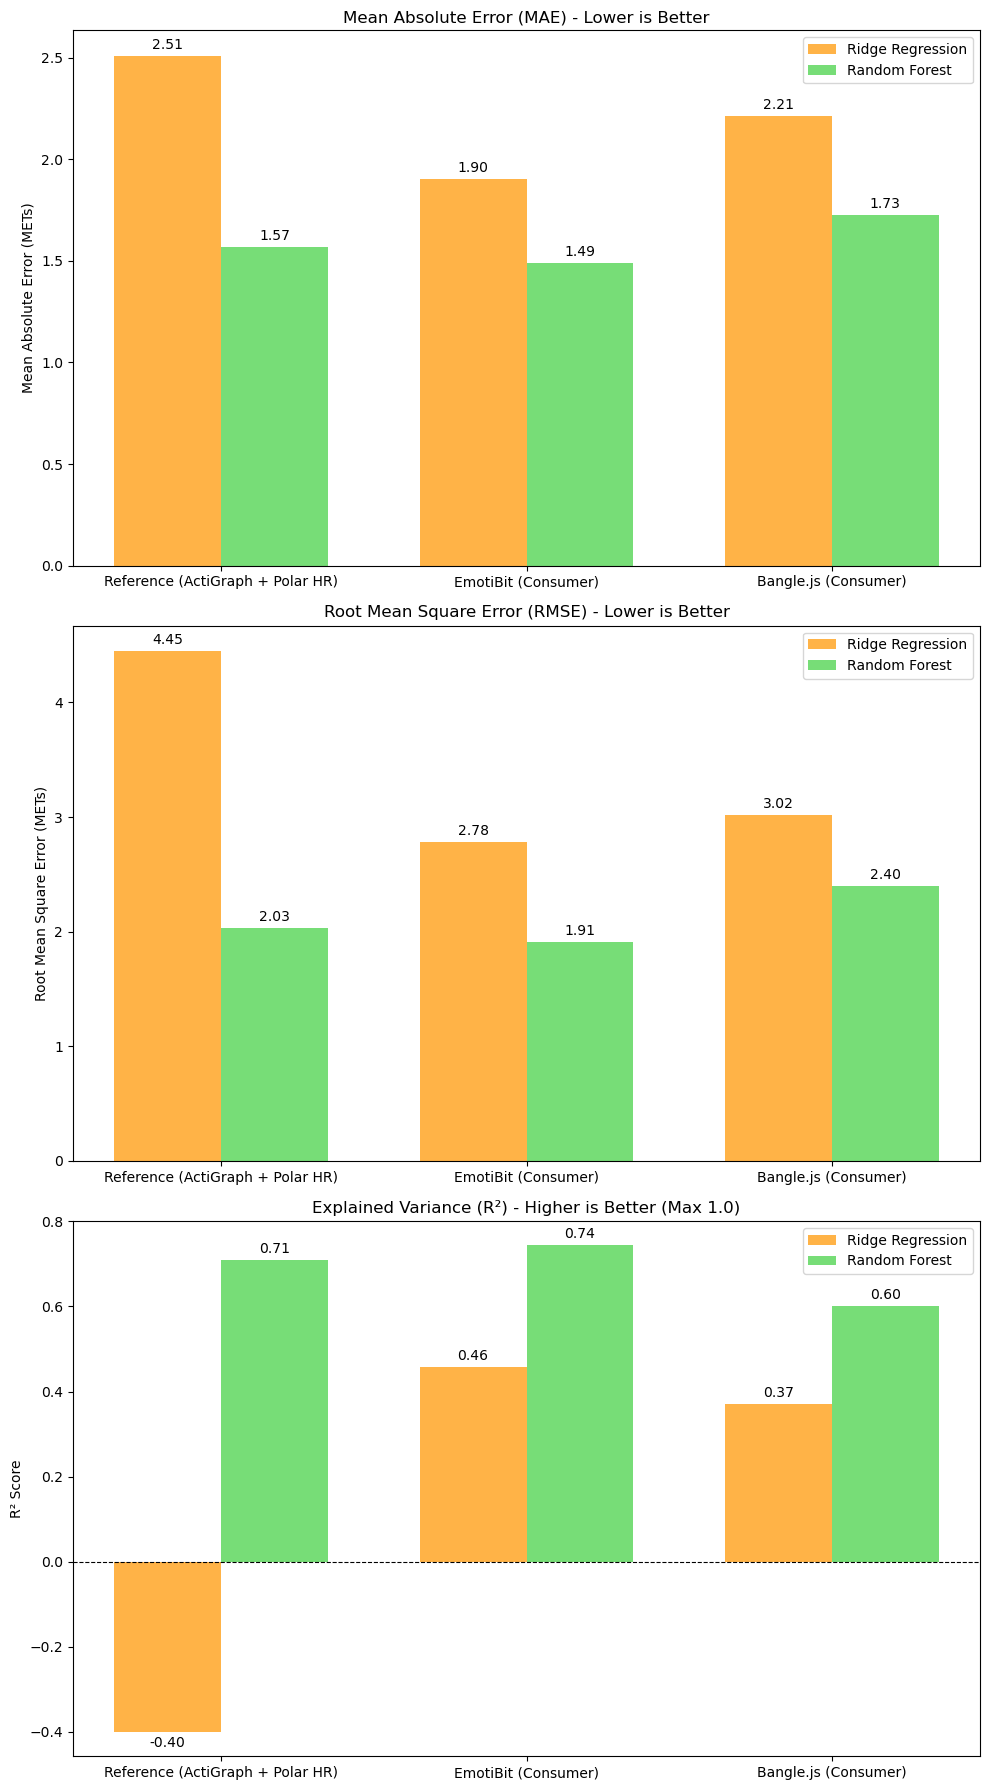

In [18]:
# Extract data for plotting
labels = [SCENARIOS[k]['label'] for k in results.keys()]

rf_maes = [results[k]['Random_Forest']['MAE_agg'] for k in results.keys()]
ridge_maes = [results[k]['Ridge']['MAE_agg'] for k in results.keys()]

rf_rmses = [results[k]['Random_Forest']['RMSE_agg'] for k in results.keys()]
ridge_rmses = [results[k]['Ridge']['RMSE_agg'] for k in results.keys()]

rf_r2 = [results[k]['Random_Forest']['R2_agg'] for k in results.keys()]
ridge_r2 = [results[k]['Ridge']['R2_agg'] for k in results.keys()]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# Create 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))

# Plot 1: MAE
rects1_mae = ax1.bar(x - width/2, ridge_maes, width, label='Ridge Regression', color='#FFB347')
rects2_mae = ax1.bar(x + width/2, rf_maes, width, label='Random Forest', color='#77DD77')
ax1.set_ylabel('Mean Absolute Error (METs)')
ax1.set_title('Mean Absolute Error (MAE) - Lower is Better')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.bar_label(rects1_mae, padding=3, fmt='%.2f')
ax1.bar_label(rects2_mae, padding=3, fmt='%.2f')

# Plot 2: RMSE
rects1_rmse = ax2.bar(x - width/2, ridge_rmses, width, label='Ridge Regression', color='#FFB347')
rects2_rmse = ax2.bar(x + width/2, rf_rmses, width, label='Random Forest', color='#77DD77')
ax2.set_ylabel('Root Mean Square Error (METs)')
ax2.set_title('Root Mean Square Error (RMSE) - Lower is Better')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.bar_label(rects1_rmse, padding=3, fmt='%.2f')
ax2.bar_label(rects2_rmse, padding=3, fmt='%.2f')

# Plot 3: R2
rects1_r2 = ax3.bar(x - width/2, ridge_r2, width, label='Ridge Regression', color='#FFB347')
rects2_r2 = ax3.bar(x + width/2, rf_r2, width, label='Random Forest', color='#77DD77')
ax3.set_ylabel('R\u00B2 Score')
ax3.set_title('Explained Variance (R\u00B2) - Higher is Better (Max 1.0)')
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.legend()
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--') # Baseline 0 line
ax3.bar_label(rects1_r2, padding=3, fmt='%.2f')
ax3.bar_label(rects2_r2, padding=3, fmt='%.2f')

fig.tight_layout()
plt.show()